In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/competitions/heavy-equipment-selling-price-prediction-challenge/sample_submission.csv
/kaggle/input/competitions/heavy-equipment-selling-price-prediction-challenge/train.csv
/kaggle/input/competitions/heavy-equipment-selling-price-prediction-challenge/metadata.csv
/kaggle/input/competitions/heavy-equipment-selling-price-prediction-challenge/test.csv


In [3]:
#importing necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
#loading datasets
df = pd.read_csv("/kaggle/input/competitions/heavy-equipment-selling-price-prediction-challenge/train.csv")
test = pd.read_csv("/kaggle/input/competitions/heavy-equipment-selling-price-prediction-challenge/test.csv")

/tmp/ipykernel_58/880258833.py:2: DtypeWarning: Columns (38,39) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("/kaggle/input/competitions/heavy-equipment-selling-price-prediction-challenge/train.csv")


# Exploratory Data Analysis (EDA)

In [5]:
df.shape

(138701, 50)

The training dataset has 13,8701 rows and 50 columns.

In [6]:
test.shape

(15000, 49)

The test dataset has 15,000 rows and 49 columns.

In [7]:
df.columns

Index(['TransactionID', 'TargetValue', 'AssetID', 'ProductConfigID',
       'DataOriginCode', 'VendorPartnerID', 'ManufactureYear',
       'OperationalHoursMeter', 'UtilizationTier', 'TransactionDate',
       'Spec_FullDescriptor', 'Spec_BaseClass', 'Spec_SubClass',
       'Spec_ReleaseSeries', 'Spec_VariantModifier', 'AssetScaleFactor',
       'FunctionalClassification', 'RegionCode', 'InventoryGroupCategory',
       'InventoryGroupDescription', 'col1', 'CabinType', 'Forks', 'col3',
       'col4', 'DrivetrainType', 'col5', 'col6', 'col7', 'col8', 'col9',
       'col10', 'col11', 'col12', 'col13', 'col14', 'col15', 'col16', 'col18',
       'col19', 'col20', 'col21', 'col22', 'col23', 'col24', 'col25', 'col27',
       'col28', 'col29', 'col30'],
      dtype='object')

In [8]:
df.head()

,TransactionID,TargetValue,AssetID,ProductConfigID,DataOriginCode,VendorPartnerID,ManufactureYear,OperationalHoursMeter,UtilizationTier,TransactionDate,...,col20,col21,col22,col23,col24,col25,col27,col28,col29,col30
0,1139309,57000.0,117665,88,ACH138,GTX,1997,4640.0,Low,2005-03-26,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Standard,Conventional
1,1139316,26500.0,1001282,4616,ACH138,GTX,2005,508.0,Low,2009-12-18,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1139317,21000.0,772709,1948,ACH138,GTX,1994,11540.0,High,2005-08-26,...,Steel,None or Unspecified,None or Unspecified,None or Unspecified,None or Unspecified,Double,NaN,NaN,NaN,NaN
3,1139322,27000.0,902010,3550,ACH138,GTX,2002,4883.0,High,2006-11-17,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1139333,21500.0,1036259,36014,ACH138,GTX,2009,302.0,Low,2010-08-27,...,Rubber,None or Unspecified,None or Unspecified,None or Unspecified,None or Unspecified,Double,NaN,NaN,NaN,NaN


In [9]:
df.dtypes

TransactionID                  int64
TargetValue                  float64
AssetID                        int64
ProductConfigID                int64
DataOriginCode                object
VendorPartnerID               object
ManufactureYear                int64
OperationalHoursMeter        float64
UtilizationTier               object
TransactionDate               object
Spec_FullDescriptor           object
Spec_BaseClass                object
Spec_SubClass                 object
Spec_ReleaseSeries            object
Spec_VariantModifier          object
AssetScaleFactor              object
FunctionalClassification      object
RegionCode                    object
InventoryGroupCategory        object
InventoryGroupDescription     object
col1                          object
CabinType                     object
Forks                         object
col3                          object
col4                          object
DrivetrainType                object
col5                          object
c

In [10]:
df.describe()

,TransactionID,TargetValue,AssetID,ProductConfigID,ManufactureYear,OperationalHoursMeter
count,1.387010e+05,138701.000000,1.387010e+05,138701.000000,138701.000000,8.205800e+04
mean,2.186276e+06,41521.874047,1.204814e+06,7286.421922,1891.640853,4.553719e+03
std,1.128497e+06,26361.125948,5.287376e+05,7542.421537,306.992001,2.792204e+04
min,1.139309e+06,7500.000000,8.000000e+00,39.000000,1001.000000,0.000000e+00
25%,1.465754e+06,20500.000000,1.007930e+06,1693.000000,1990.000000,0.000000e+00
50%,1.751884e+06,35000.000000,1.246956e+06,3852.000000,1998.000000,1.620000e+03
75%,2.372139e+06,57000.000000,1.495817e+06,11873.000000,2004.000000,5.001000e+03
max,6.333410e+06,142000.000000,2.478476e+06,37209.000000,2015.000000,1.729600e+06


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 138701 entries, 0 to 138700
Data columns (total 50 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   TransactionID              138701 non-null  int64  
 1   TargetValue                138701 non-null  float64
 2   AssetID                    138701 non-null  int64  
 3   ProductConfigID            138701 non-null  int64  
 4   DataOriginCode             138701 non-null  object 
 5   VendorPartnerID            138701 non-null  object 
 6   ManufactureYear            138701 non-null  int64  
 7   OperationalHoursMeter      82058 non-null   float64
 8   UtilizationTier            50475 non-null   object 
 9   TransactionDate            138701 non-null  object 
 10  Spec_FullDescriptor        138701 non-null  object 
 11  Spec_BaseClass             138701 non-null  object 
 12  Spec_SubClass              101716 non-null  object 
 13  Spec_ReleaseSeries         32

In [12]:
df.duplicated().sum()

np.int64(0)

This indicates no completely identical rows are present.

****# Missing Values Analysis****

In [13]:
df.isnull().sum().sort_values(ascending=False)

col19                        138635
col18                        138635
col5                         128320
col4                         128320
col27                        123742
col28                        123742
col29                        119829
col30                        119829
col13                        115296
col14                        115296
col7                         115296
col6                         115296
col9                         115296
col8                         115296
col11                        115296
col3                         109448
Forks                        109382
Spec_ReleaseSeries           105805
col1                         104915
col12                        100337
col15                         96424
DrivetrainType                89956
UtilizationTier               88226
Spec_VariantModifier          86369
col20                         67685
col25                         67685
col21                         67685
col22                       

In [14]:
missing_percent = (df.isnull().sum()/len(df))*100
missing_percent = missing_percent.sort_values(ascending = False)
missing_percent

col19                        99.952416
col18                        99.952416
col5                         92.515555
col4                         92.515555
col27                        89.214930
col28                        89.214930
col29                        86.393753
col30                        86.393753
col13                        83.125572
col14                        83.125572
col7                         83.125572
col6                         83.125572
col9                         83.125572
col8                         83.125572
col11                        83.125572
col3                         78.909309
Forks                        78.861724
Spec_ReleaseSeries           76.282795
col1                         75.641127
col12                        72.340502
col15                        69.519326
DrivetrainType               64.856057
UtilizationTier              63.608770
Spec_VariantModifier         62.269919
col20                        48.799216
col25                    

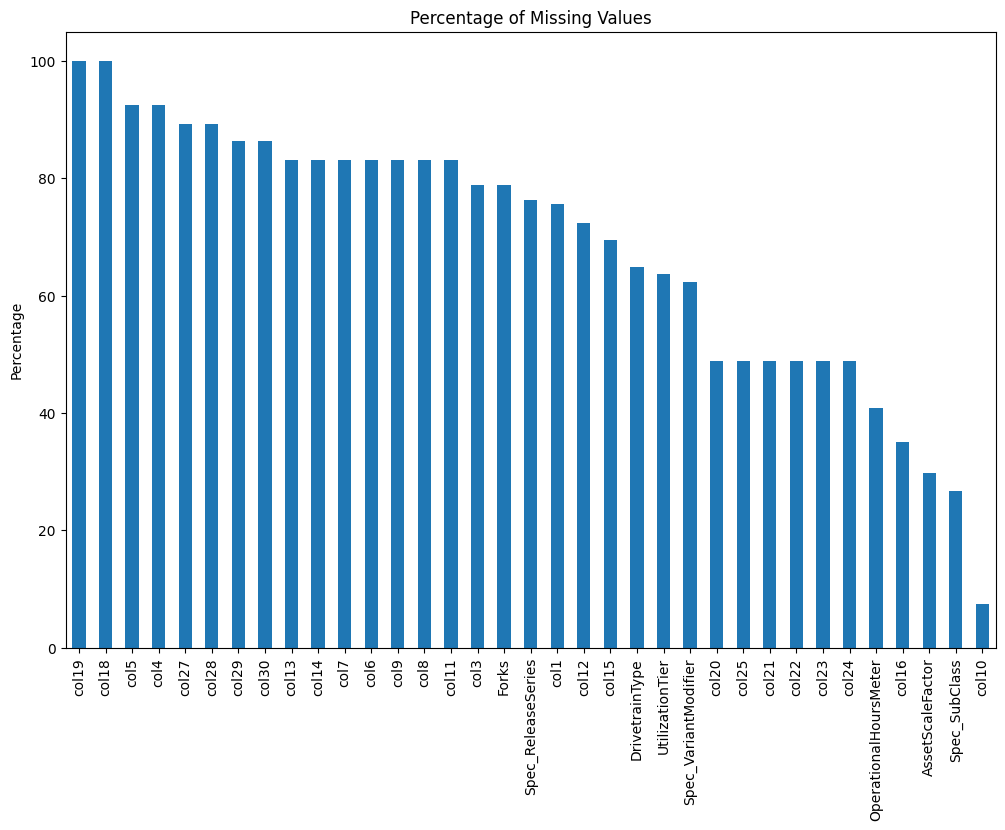

In [15]:
import matplotlib.pyplot as plt
plt.figure(figsize = (12,8))
missing_percent[missing_percent > 0].plot(kind = 'bar')

plt.title("Percentage of Missing Values")
plt.ylabel("Percentage")
plt.xticks(rotation=90)
plt.show()


The dataset contains a substantial amount of missing data, but the missingness is not uniform across features.

Some columns are almost complete, while others are almost entirely missing.

1. col18 and col19 have almost 100% missing values
2. Several columns have more than 80% missing values.
3. OperationalHoursMeter has around 41% missing values.
4. Some important columns, like TargetValue, ManufactureYear, Spec_FullDescriptor, Spec_BaseClass,
have no missing values


****Target Variable Analysis****

In [16]:
df['TargetValue'].describe()

count    138701.000000
mean      41521.874047
std       26361.125948
min        7500.000000
25%       20500.000000
50%       35000.000000
75%       57000.000000
max      142000.000000
Name: TargetValue, dtype: float64

In [17]:
df['TargetValue'].nlargest()

3141     142000.0
14403    142000.0
15329    142000.0
36160    142000.0
36163    142000.0
Name: TargetValue, dtype: float64

In [18]:
df['TargetValue'].nsmallest()

221     7500.0
293     7500.0
599     7500.0
1165    7500.0
1382    7500.0
Name: TargetValue, dtype: float64

In [19]:
df['TargetValue'].skew()

np.float64(0.9699963984208283)

TargetValue has positive (right) skewness, approximately 0.97 which means most transactions have relatively lower/moderate values, while a smaller number of transactions have very high TargetValue, creating a long tail toward the right.

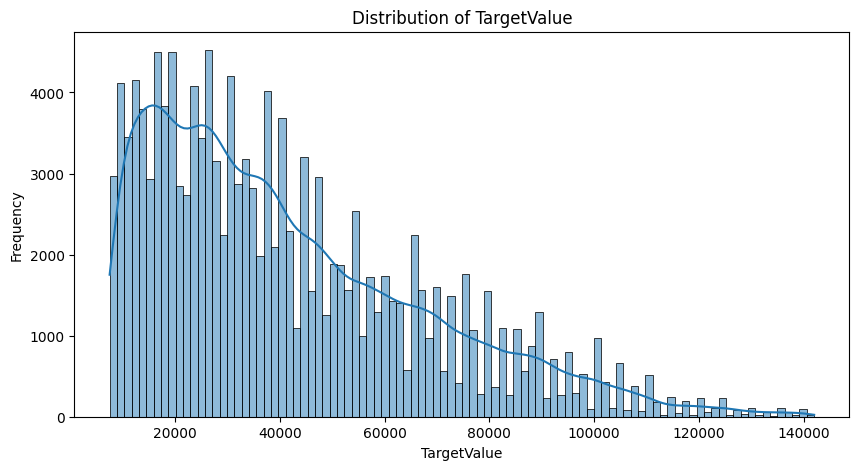

In [20]:
plt.figure(figsize = (10,5))
sns.histplot(df['TargetValue'],kde=True)
plt.title("Distribution of TargetValue")
plt.xlabel("TargetValue")
plt.ylabel("Frequency")
plt.show()

This clearly shows most transactions have been made with lower to moderate values while the higher target values have very low frequency , hence it's **rightly skewed**.

In [21]:
print("Mean:", df['TargetValue'].mean())
print("Median:", df['TargetValue'].median())

Mean: 41521.87404705085
Median: 35000.0


Again, it's mean > median which means its right skewed

**Hence I Conclude:** 

1.  Most transactions have relatively lower values.
The highest frequencies appear roughly around $10,000–$40,000.

2. There is a long right tail.
Values extend to around $140,000, but the frequency becomes very low as the transaction value increases.

3. There are relatively few high-value transactions.
The observations above roughly $80,000–$100,000 are much less frequent than the lower-value observations.

4. The target is not normally distributed.
It has a noticeably asymmetric shape rather than a bell-shaped distribution.

**Log Transformation of TargetValue**

Selling prices are typically right-skewed: a small number of expensive machines can be much more expensive than the majority. Log transformation compresses those large values and makes the target distribution easier for the model to learn. As the competition metric is RMSLE, evaluating on the log-transformed target is also aligned with the evaluation metric.

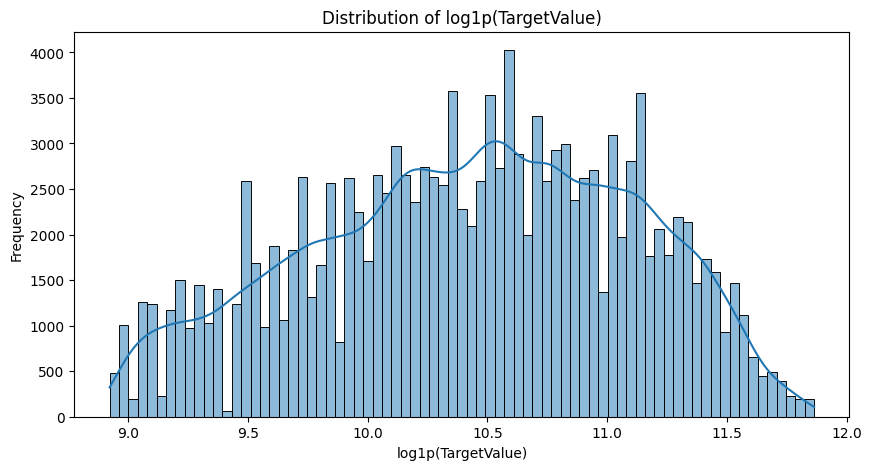

In [22]:
import numpy as np
log_target = np.log1p(df['TargetValue'])
plt.figure(figsize = (10,5))
sns.histplot(log_target, kde=True)
plt.title("Distribution of log1p(TargetValue)")
plt.xlabel("log1p(TargetValue)")
plt.ylabel("Frequency")
plt.show()

The values are now concentrated around roughly 10–11.5, and the extreme right tail has been substantially compressed.

The target variable is positively skewed, with a long right tail caused by relatively high-valued transactions. To reduce the influence of extreme target values and obtain a more balanced target distribution, a log1p transformation was examined. The transformed distribution is substantially less right-skewed, so the log-transformed target is used for model training.

**Boxplot of TargetValue**

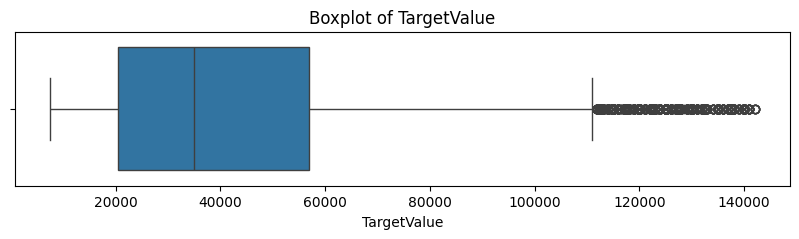

In [23]:
plt.figure(figsize=(10,2))
sns.boxplot(x=df['TargetValue'])

plt.title("Boxplot of TargetValue")
plt.show()

**Observations:**
1. Most values are between roughly $21,000   and   $57,000.


   The box represents the middle 50% of transactions.

3. Q1 ≈ $21,000 (Value below which 25% of observations fall)

4.  Median ≈ $35,000 (Median — half below, half above)


Q3 ≈ $57,000 (Value below which 75% of observations fall)

   
   Therefore, IQR is Q3 − Q1, the range containing the middle 50% i.e. ≈ $37,000.

5. From the boxplot we can see the Upper bound (i.e Q3 + 1.5(IQR) = 57,000+1.5(37,000)) is $1,12,500 .

   
    

This dataset is about heavy equipment.

Some machines are naturally much more expensive because they may:

Have higher capacity.
Be newer.
Have premium specifications.
Be specialized equipment.

These are likely valid observations, not data entry errors.

I would not remove them at this stage.

My goal is to predict the price of all machines, including expensive ones.
These values are part of the distribution.
Removing them could make the model worse at predicting high-value equipment.

**Separating the columns by type**

In [24]:
num_cols = df.select_dtypes(include = np.number).columns.tolist()
cat_cols = df.select_dtypes(include = ["object","category"]).columns.tolist()

print("Numerical Columns : ")
print(num_cols)

print("\nCategorical Columns : ")
print(cat_cols)

Numerical Columns : 
['TransactionID', 'TargetValue', 'AssetID', 'ProductConfigID', 'ManufactureYear', 'OperationalHoursMeter']

Categorical Columns : 
['DataOriginCode', 'VendorPartnerID', 'UtilizationTier', 'TransactionDate', 'Spec_FullDescriptor', 'Spec_BaseClass', 'Spec_SubClass', 'Spec_ReleaseSeries', 'Spec_VariantModifier', 'AssetScaleFactor', 'FunctionalClassification', 'RegionCode', 'InventoryGroupCategory', 'InventoryGroupDescription', 'col1', 'CabinType', 'Forks', 'col3', 'col4', 'DrivetrainType', 'col5', 'col6', 'col7', 'col8', 'col9', 'col10', 'col11', 'col12', 'col13', 'col14', 'col15', 'col16', 'col18', 'col19', 'col20', 'col21', 'col22', 'col23', 'col24', 'col25', 'col27', 'col28', 'col29', 'col30']


# **Numerical Feature Analysis**

**'ManufactureYear**

In [25]:
df['ManufactureYear'].describe()

count    138701.000000
mean       1891.640853
std         306.992001
min        1001.000000
25%        1990.000000
50%        1998.000000
75%        2004.000000
max        2015.000000
Name: ManufactureYear, dtype: float64

In [26]:
df['ManufactureYear'].value_counts().head(10)

ManufactureYear
1001    14719
2006    10895
2005     9564
1999     7243
2007     7133
1998     6447
1997     6151
2000     6096
2004     6019
2001     5764
Name: count, dtype: int64

In [27]:
df[df["ManufactureYear"] == 1001]["TargetValue"].describe()

count     14719.000000
mean      26428.737346
std       18384.796611
min        7500.000000
25%       13250.000000
50%       21000.000000
75%       33000.000000
max      140000.000000
Name: TargetValue, dtype: float64

In [28]:
df[df["ManufactureYear"] != 1001]["TargetValue"].describe()

count    123982.000000
mean      43313.713823
std       26590.004592
min        7500.000000
25%       22000.000000
50%       37000.000000
75%       60000.000000
max      142000.000000
Name: TargetValue, dtype: float64

ManufactureYear contains an anomalous value of 1001 occurring in 14,719 records. This value is inconsistent with the main distribution, whose median is 1998, suggesting that 1001 is likely a placeholder for an unknown or invalid manufacturing year. However, these observations contain valid target and other feature information, so the rows should not be removed. Instead, the anomalous year will be treated as missing and handled through the preprocessing pipeline.

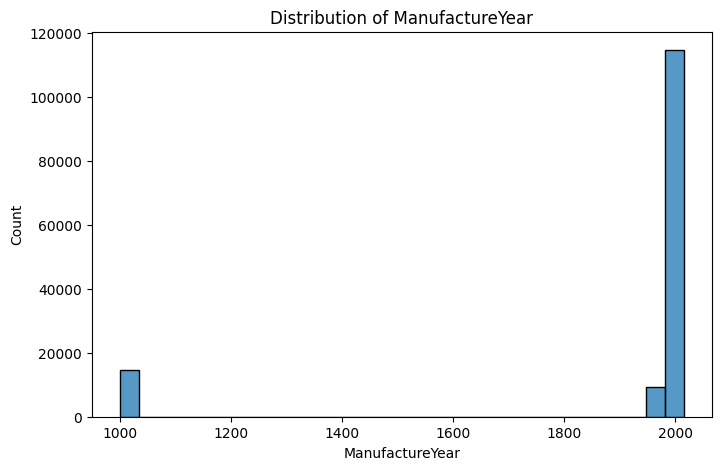

In [29]:
plt.figure(figsize=(8,5))
sns.histplot(df['ManufactureYear'], bins=30)
plt.title("Distribution of ManufactureYear")
plt.show()

There is a huge gap between 1000 and the actual manufacturing years.
That immediately tells us something is wrong.

Most machines were manufactured between approximately 1990 and 2012.
There is a separate spike at 1000/1001.
There are no years between 1001 and the 1900s.

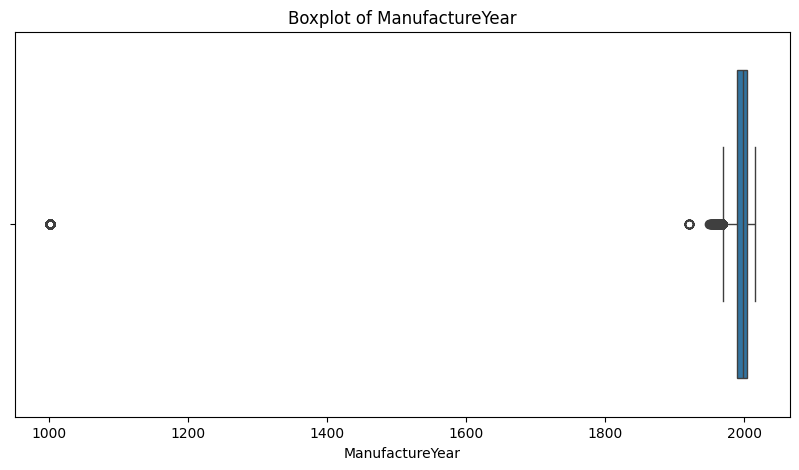

In [30]:
plt.figure(figsize = (10,5))
sns.boxplot(x=df['ManufactureYear'])
plt.title("Boxplot of ManufactureYear")
plt.xlabel("ManufactureYear")
plt.show()

Most observations are tightly grouped around recent years.
One point is extremely far away at 1000.

That point isn't simply an "old machine".

It represents bad data.

Instead of deleting those rows, we should replace them with missing values.

In [31]:
df['ManufactureYear'] = df['ManufactureYear'].replace([1000, 1001], np.nan)

In [32]:
df['ManufactureYear'].describe()

count    123982.000000
mean       1997.376708
std           8.895847
min        1920.000000
25%        1994.000000
50%        1999.000000
75%        2005.000000
max        2015.000000
Name: ManufactureYear, dtype: float64

In [33]:
df['ManufactureYear'].value_counts().head(10)

ManufactureYear
2006.0    10895
2005.0     9564
1999.0     7243
2007.0     7133
1998.0     6447
1997.0     6151
2000.0     6096
2004.0     6019
2001.0     5764
1996.0     5673
Name: count, dtype: int64

In [34]:
df[["ManufactureYear", "TargetValue"]].corr()

,ManufactureYear,TargetValue
ManufactureYear,1.000000,0.276962
TargetValue,0.276962,1.000000


ManufactureYear has a positive Pearson correlation of approximately 0.204 with TargetValue. This suggests that newer equipment tends to have somewhat higher selling prices, although the relationship is not strong enough to explain the target by itself.

****OperationalHoursMeter****

In [35]:
df["OperationalHoursMeter"].describe()

count    8.205800e+04
mean     4.553719e+03
std      2.792204e+04
min      0.000000e+00
25%      0.000000e+00
50%      1.620000e+03
75%      5.001000e+03
max      1.729600e+06
Name: OperationalHoursMeter, dtype: float64

The mean (approx.4,554 hours) is much larger than the median (approx.1,620 hours).
This is a strong clue that this feature is right-skewed. A few machines with extremely high operating hours are pulling the average upward.

The mean is much higher than the median because a few very large values pull the average upward. Since the median is more robust to outliers, it is a safer choice for imputing missing values.

The standard deviation is approx.27,922 which is much larger than the median 1,620 .
The maximum value of 1,729,600 is far above the third quartile of approx.5,001, indicating the presence of extreme upper-tail observations.
Therefore, the feature has substantial dispersion and an influential upper tail.

In [36]:
(df["OperationalHoursMeter"] == 0).mean() * 100

np.float64(22.77056401900491)

Also, we see approx. 23% = 0, and since the minimum is 0, this strongly suggests many machines have 0 recorded operational hours.

In [37]:
df["OperationalHoursMeter"].sort_values(ascending=False).head(20)

81091     1729600.0
87636     1728600.0
87562     1711700.0
98066     1602900.0
83197     1485900.0
98727     1429800.0
85150     1282700.0
98240     1209500.0
98243     1203000.0
96489     1194900.0
98959     1189500.0
98241     1148500.0
91894     1112100.0
78958     1098000.0
90301      991000.0
98370      974400.0
110287     968400.0
88674      945300.0
108061     934400.0
88741      922100.0
Name: OperationalHoursMeter, dtype: float64

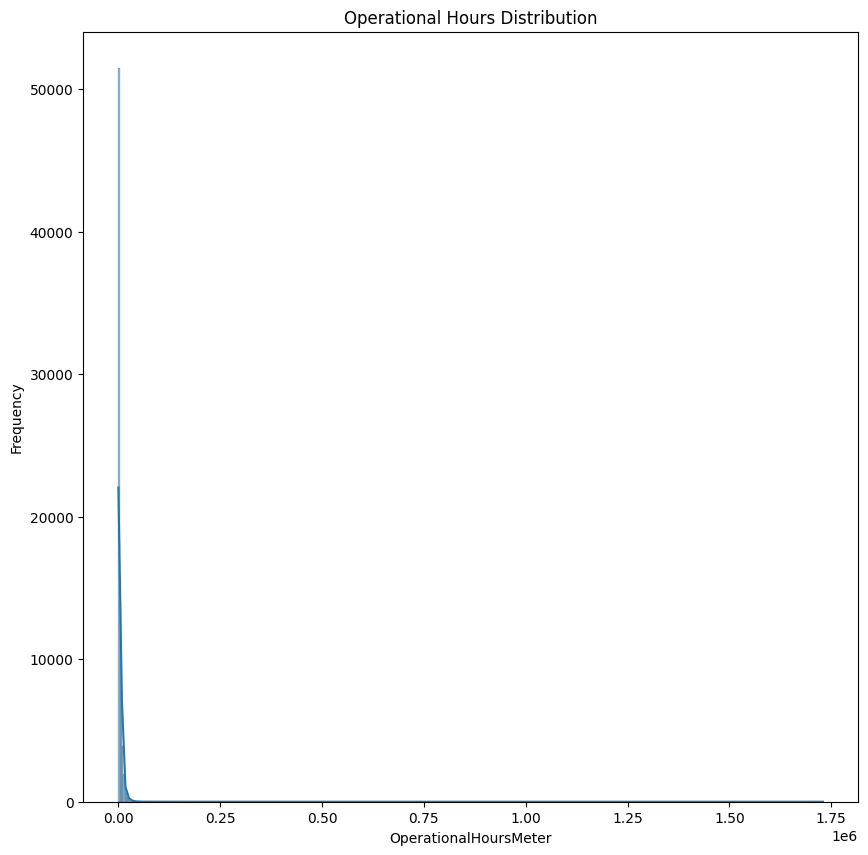

In [38]:
plt.figure(figsize=(10,10))
sns.histplot(df['OperationalHoursMeter'],kde=True)
plt.title('Operational Hours Distribution')
plt.xlabel('OperationalHoursMeter')
plt.ylabel('Frequency')
plt.show()

The Histogram confirms the above observations :
1. Most observations are concentrated very close to the left side.
2. There is a very long right tail.
3. The x-axis stretches all the way to about 1.73 million because of the extreme maximum.
4. This makes the central distribution difficult to see clearly.
but again, we get to know its extreme right skew

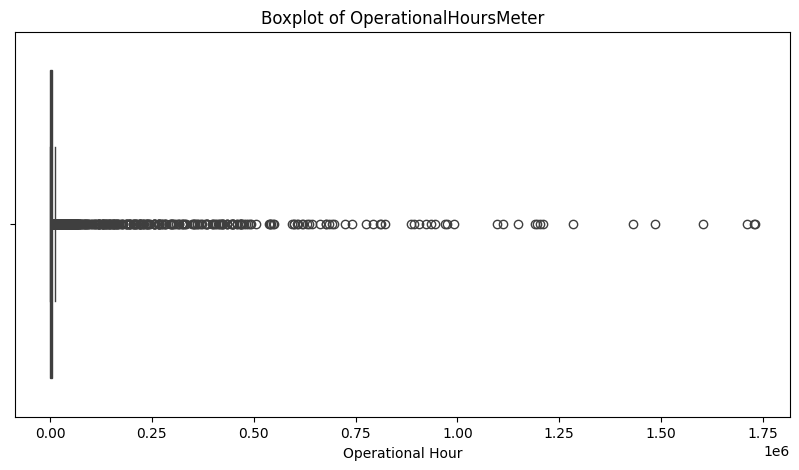

In [39]:
plt.figure(figsize=(10,5))
sns.boxplot(x=df["OperationalHoursMeter"])
plt.title("Boxplot of OperationalHoursMeter")
plt.xlabel("Operational Hour")
plt.show()

The box (IQR) is compressed extremely close to 0, while there are many points extending far to the right.The circles are statistical outliers.

The boxplot identifies numerous upper-tail observations as statistical outliers under the IQR criterion(Q3 + 1.5(IQR)). 
However, I did not automatically remove them because an extreme operating-hour value may represent a legitimate heavy-use machine. Instead, I considered the skewness during preprocessing and model selection.

In [40]:
df[["OperationalHoursMeter","TargetValue"]].corr()

,OperationalHoursMeter,TargetValue
OperationalHoursMeter,1.000000,0.001994
TargetValue,0.001994,1.000000


The Pearson correlation between OperationalHoursMeter and TargetValue is approximately 0.002, indicating almost no linear relationship between the two variables.

# Categorical Features Analysis

All Categorical columns

In [41]:
cat_cols = df.select_dtypes(include = ["object","category"]).columns
cat_cols  

Index(['DataOriginCode', 'VendorPartnerID', 'UtilizationTier',
       'TransactionDate', 'Spec_FullDescriptor', 'Spec_BaseClass',
       'Spec_SubClass', 'Spec_ReleaseSeries', 'Spec_VariantModifier',
       'AssetScaleFactor', 'FunctionalClassification', 'RegionCode',
       'InventoryGroupCategory', 'InventoryGroupDescription', 'col1',
       'CabinType', 'Forks', 'col3', 'col4', 'DrivetrainType', 'col5', 'col6',
       'col7', 'col8', 'col9', 'col10', 'col11', 'col12', 'col13', 'col14',
       'col15', 'col16', 'col18', 'col19', 'col20', 'col21', 'col22', 'col23',
       'col24', 'col25', 'col27', 'col28', 'col29', 'col30'],
      dtype='object')

In [42]:
cat_summary = pd.DataFrame({
    "unique": df[cat_cols].nunique(dropna = False),
    "missing": df[cat_cols].isna().sum(),
    "missing_pct": df[cat_cols].isna().mean() * 100 
}).sort_values("unique")
cat_summary

,unique,missing,missing_pct
CabinType,3,0,0.000000
col9,3,115296,83.125572
col13,3,115296,83.125572
col11,3,115296,83.125572
col5,3,128320,92.515555
col6,3,115296,83.125572
col4,3,128320,92.515555
Forks,3,109382,78.861724
col30,3,119829,86.393753
col20,3,67685,48.799216


The four strongest & cleanest categorical features

In [43]:
eda_cat_cols = [
    "CabinType",
    "InventoryGroupCategory",
    "DataOriginCode",
    "InventoryGroupDescription"]
     

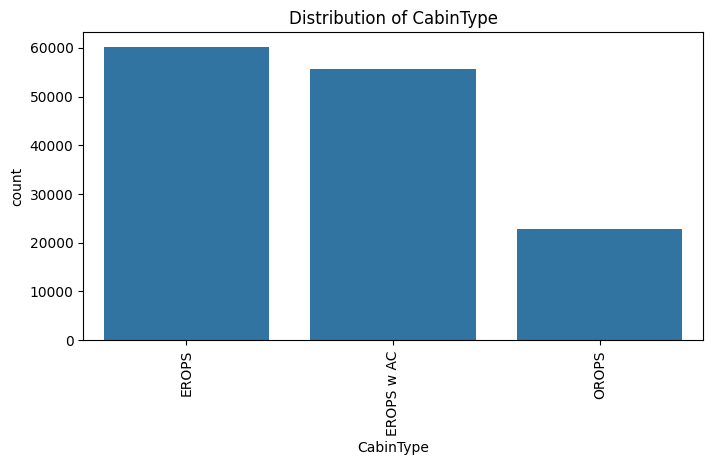

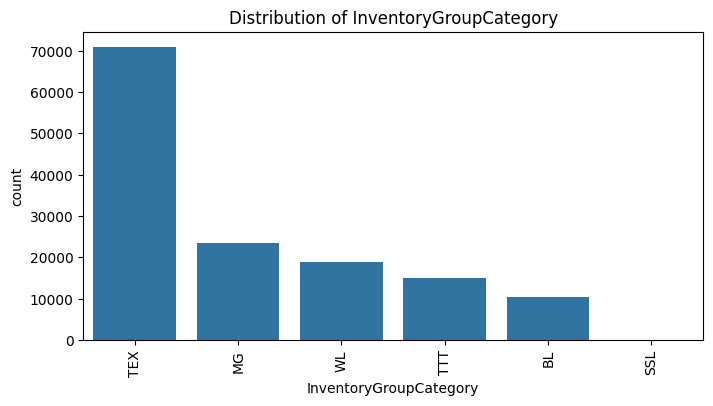

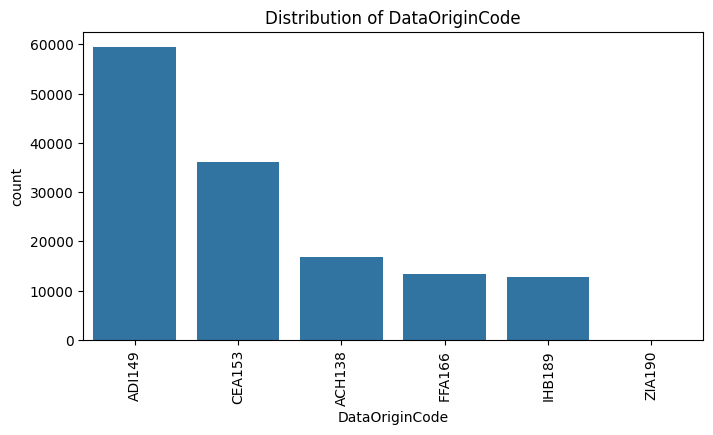

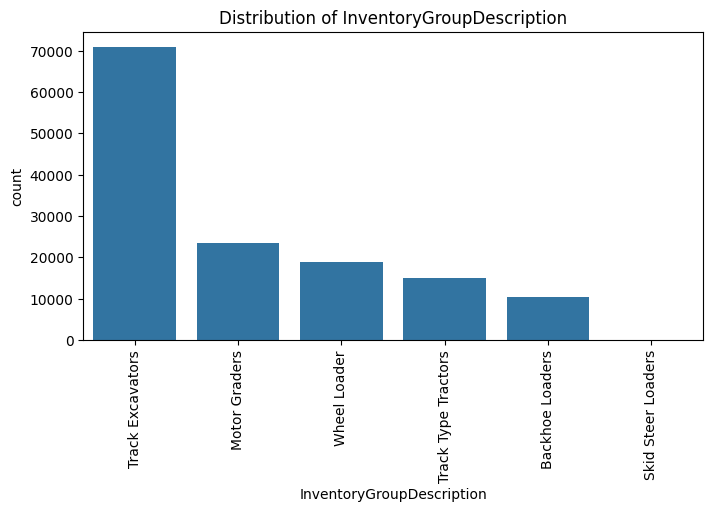

In [44]:
for col in eda_cat_cols:
    plt.figure(figsize=(8, 4))

    sns.countplot(
        data=df,
        x=col,
        order=df[col].value_counts().index
    )

    plt.title(f"Distribution of {col}")
    plt.xticks(rotation=90)

    plt.show()

1. CabinType is mostly dominated by 2 types.
2. In InventoryGroupCategory we can see "TEX" dominates over entire feature while other values have much lower frequency
3. The DataOriginCode the feature is  mostly balanced.
4. InventoryGroupDescription one value is mostly dominating the entire feature.

In [45]:
df["RegionCode"].value_counts().head(15)

RegionCode
Florida           23460
Texas             18284
California         9525
Washington         6063
Georgia            5240
North Carolina     4391
Maryland           4352
Mississippi        4227
Colorado           3989
Illinois           3855
Alabama            3723
Tennessee          3602
Ohio               3528
South Carolina     3386
New Jersey         3370
Name: count, dtype: int64

Florida accounts for the highest volume of machinery transaction.

In [46]:
df["FunctionalClassification"].value_counts().head(10)

FunctionalClassification
Hydraulic Excavator, Track - 21.0 to 24.0 Metric Tons      11158
Motorgrader - 145.0 to 170.0 Horsepower                     8107
Hydraulic Excavator, Track - 12.0 to 14.0 Metric Tons       7625
Backhoe Loader - 14.0 to 15.0 Ft Standard Digging Depth     7603
Hydraulic Excavator, Track - 33.0 to 40.0 Metric Tons       7440
Motorgrader - 45.0 to 130.0 Horsepower                      6447
Hydraulic Excavator, Track - 19.0 to 21.0 Metric Tons       5558
Wheel Loader - 150.0 to 175.0 Horsepower                    5124
Motorgrader - 130.0 to 145.0 Horsepower                     5065
Hydraulic Excavator, Track - 28.0 to 33.0 Metric Tons       4968
Name: count, dtype: int64

The most frequently traded machinery classification is a tracked hydraulic excavator in the 21–24 metric ton range, with 11,158 observations.

I initially identified features with more than 50% missing values. Rather than applying an arbitrary cutoff and immediately deleting them, I considered both missingness and potential predictive usefulness. Features with extremely high missingness were strong candidates for removal, while moderately high-missing features were retained initially and evaluated during modeling.

# Feature Engineering

**Creating copy of Dataset**

In [47]:
df1 = df.copy()
test1 = test.copy()

In [48]:
df1.columns

Index(['TransactionID', 'TargetValue', 'AssetID', 'ProductConfigID',
       'DataOriginCode', 'VendorPartnerID', 'ManufactureYear',
       'OperationalHoursMeter', 'UtilizationTier', 'TransactionDate',
       'Spec_FullDescriptor', 'Spec_BaseClass', 'Spec_SubClass',
       'Spec_ReleaseSeries', 'Spec_VariantModifier', 'AssetScaleFactor',
       'FunctionalClassification', 'RegionCode', 'InventoryGroupCategory',
       'InventoryGroupDescription', 'col1', 'CabinType', 'Forks', 'col3',
       'col4', 'DrivetrainType', 'col5', 'col6', 'col7', 'col8', 'col9',
       'col10', 'col11', 'col12', 'col13', 'col14', 'col15', 'col16', 'col18',
       'col19', 'col20', 'col21', 'col22', 'col23', 'col24', 'col25', 'col27',
       'col28', 'col29', 'col30'],
      dtype='object')

**Dropping Columns with extreme missing values and IDs**

In [49]:
drop_cols = ["TransactionID",
    "AssetID",
    "ProductConfigID",
    "col18",
    "col19",
    "col4",
    "col5"]
df1.drop(columns = drop_cols, inplace = True)

In [50]:
for da in [df1,test1]:
    da['TransactionDate'] = pd.to_datetime(da['TransactionDate'],errors = 'coerce')

    da['TransactionYear'] = da['TransactionDate'].dt.year
    da['TransactionQuarter'] = da['TransactionDate'].dt.quarter

    da['ManufactureYear'] = da['ManufactureYear'].replace([1000,1001], np.nan)

    da['AssetAge'] = (da['TransactionYear'] - da['ManufactureYear'])

    da['DescriptorLength'] = (da['Spec_FullDescriptor'].fillna("").astype(str).str.len())

    da['HasOperationalHours'] = (da['OperationalHoursMeter'].notna().astype(int))

    da['HasVariantModifier'] = (da['Spec_VariantModifier'].notna().astype(int))

In [51]:
print((df1["AssetAge"] < 0).sum())

7


In [52]:
df1[df1["AssetAge"] < 0][
    ["ManufactureYear", "TransactionYear", "AssetAge"]
]

,ManufactureYear,TransactionYear,AssetAge
17184,1998.0,1997,-1.0
56027,1999.0,1997,-2.0
71259,2003.0,1996,-7.0
79839,2013.0,2011,-2.0
81386,2010.0,2009,-1.0
135866,2014.0,2012,-2.0
136481,2015.0,2013,-2.0


In [53]:
df1.loc[df1["AssetAge"] < 0, "AssetAge"] = np.nan
test1.loc[test1["AssetAge"] < 0, "AssetAge"] = np.nan

In [54]:
for da in [df1, test1]:
    da["HoursPerYear"] = (da["OperationalHoursMeter"] /da["AssetAge"].replace(0, np.nan))

**AssetAge** : I created AssetAge because machinery value generally depends on its age at the time of sale. Instead of relying only on the raw manufacture year, I calculated the actual age using TransactionYear minus ManufactureYear, making the feature more directly relevant to depreciation and resale value.

**DescriptorLength** : The model can't directly understand the semantic meaning of the raw text in this pipeline, but the length of the description can potentially capture differences in specification/detail.

**HasOperationalHours** : I created a missingness indicator because the absence of operational-hour information may itself contain predictive information, rather than treating missingness as completely random.

**HasVariantModifier** : I converted the presence of a variant modifier into a binary feature so that the model can use missingness as an explicit signal.

**HoursPerYear** : HoursPerYear is an intensity feature representing average annual machine usage. I calculated it by dividing operational hours by asset age. I only perform the division when asset age is positive to avoid division-by-zero and invalid values.

**AssetAge vs TargetValue**

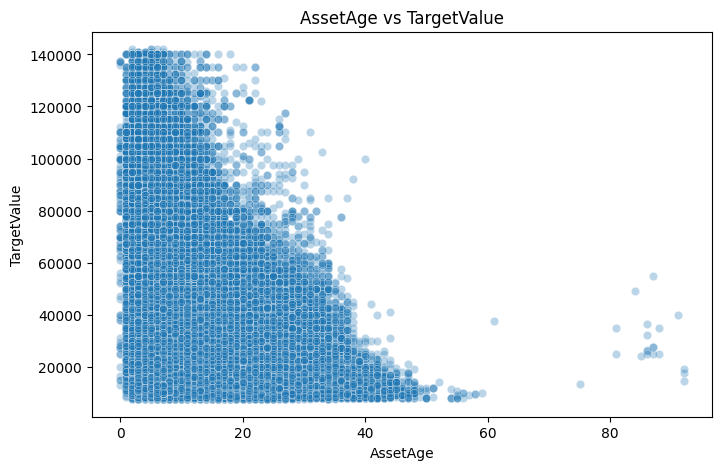

Correlation: -0.34942476309373366


In [55]:
plt.figure(figsize=(8,5))
sns.scatterplot(x=df1['AssetAge'], y=df1['TargetValue'], alpha=0.3)
plt.title("AssetAge vs TargetValue")
plt.show()
print("Correlation:", df1['AssetAge'].corr(df1['TargetValue']))

As AssetAge increases, the maximum TargetValue decreases.
Newer machines (0–15 years) have a wide range of prices.
Older machines (>40 years) are almost always inexpensive.
There are only a few very old machines (80–90 years).

This suggests a negative relationship between age and price.

**OperationalHoursMeter vs TargetValue**

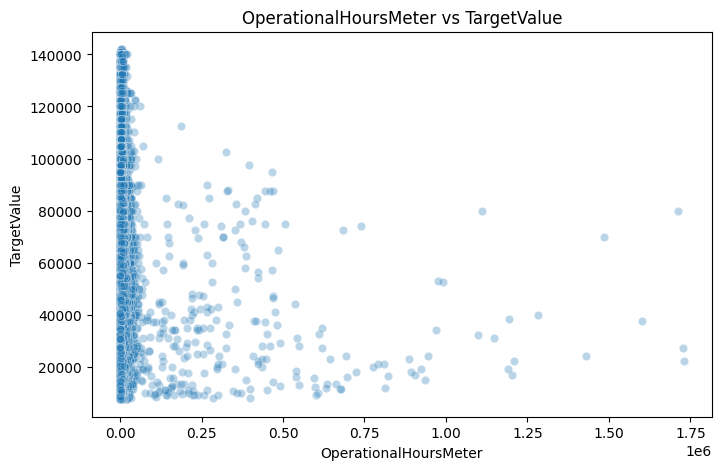

Correlation:  0.0019936232351365837


In [56]:
plt.figure(figsize=(8,5))
sns.scatterplot(x=df1['OperationalHoursMeter'], y=df1['TargetValue'], alpha=0.3)
plt.title("OperationalHoursMeter vs TargetValue")
plt.show()
print("Correlation: ",df1['OperationalHoursMeter'].corr(df1['TargetValue']))

1. Most machines have relatively low operational hours.
2. There isn't a clear linear relationship.
3. There are some extreme operational-hour values.
4. At low operational hours, target values vary widely.

 # Building the Preprocessing Pipeline

Separating features and target

In [57]:
X = df1.drop('TargetValue', axis=1)
y = np.log1p(df1['TargetValue'])

**Train-Test Split**

In [58]:
from sklearn.model_selection import train_test_split
X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size = 0.2, random_state = 42)
print(X_train.shape, X_valid.shape, y_train.shape, y_valid.shape)

(110960, 49) (27741, 49) (110960,) (27741,)


Identifying Column types

In [59]:
cat_cols = X_train.select_dtypes(include=['object','category']).columns.tolist()

num_cols = X_train.select_dtypes(include = np.number).columns.tolist()

print("Categorical:", len(cat_cols))
print("Numerical:", len(num_cols))

Categorical: 39
Numerical: 9


Building Preprocessors

In [60]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

In [61]:
numeric_pipeline = Pipeline([
    ("imputer",SimpleImputer(strategy = "median")),
    ("scaler",StandardScaler())
])

Median is more robust than mean when variables contain extreme outliers, which in OperationalHoursMeter clearly does.

In [62]:
categorical_pipeline = Pipeline([
    ("imputer",SimpleImputer(strategy = "most_frequent")),
    ("encoder",OneHotEncoder(handle_unknown = "ignore", sparse_output = True))
])

Combining both pipelines Using ColumnTransformer

In [63]:
preprocessor = ColumnTransformer([
    ("num",numeric_pipeline,num_cols),
    ("cat",categorical_pipeline,cat_cols)
],remainder = "drop")

In [64]:
X_train_processed = preprocessor.fit_transform(X_train)

X_valid_processed = preprocessor.transform(X_valid)

test_processed = preprocessor.transform(test1)

print("Training shape:", X_train_processed.shape)
print("Validation shape:", X_valid_processed.shape)
print("Test shape:", test_processed.shape)


Training shape: (110960, 5245)
Validation shape: (27741, 5245)
Test shape: (15000, 5245)


# Model Building

Since this is a regression problem, multiple tree-based boosting models are evaluated. LightGBM, XGBoost, and CatBoost are selected because they can model nonlinear relationships and interactions between machine characteristics effectively.

# Model 1

In [65]:
from lightgbm import LGBMRegressor

lgbm_model = LGBMRegressor(
    n_estimators = 1000,
    learning_rate = 0.03,
    max_depth = -1,
    num_leaves = 31,
    subsample = 0.8,
    colsample_bytree=0.8,
    random_state=42,
    verbosity=-1
)
lgbm_model.fit(X_train_processed, y_train)

LGBMRegressor(colsample_bytree=0.8, learning_rate=0.03, n_estimators=1000,
              random_state=42, subsample=0.8, verbosity=-1)

In [66]:
lgbm_valid_pred = lgbm_model.predict(X_valid_processed)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


Evaluating using rmse

In [67]:
from sklearn.metrics import mean_squared_error

lgbm_rmse = np.sqrt(mean_squared_error(y_valid, lgbm_valid_pred))

print("LightGBM Validation RMSE:", lgbm_rmse)

LightGBM Validation RMSE: 0.23385693516523384


I evaluate RMSE on the log-transformed target because the competition metric is RMSLE. RMSE on log-transformed prices is closely aligned with RMSLE

In [68]:
print("Training shape:", X_train_processed.shape)

Training shape: (110960, 5245)


# Model 2

XGBoost is another gradient-boosted decision-tree model. It is evaluated independently to determine whether it captures nonlinear patterns differently from LightGBM

In [69]:
from xgboost import XGBRegressor

xgb_model = XGBRegressor(
    n_estimators  = 1000,
    learning_rate = 0.03,
    max_depth=8,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42
)
xgb_model.fit(X_train_processed, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.03, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=8,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=1000,
             n_jobs=None, num_parallel_tree=None, ...)

In [70]:
xgb_valid_pred = xgb_model.predict(X_valid_processed)

In [71]:
from sklearn.metrics import mean_squared_error
xgb_rmse = np.sqrt(mean_squared_error(y_valid,xgb_valid_pred))
print("XGBoost Validation RMSE:", xgb_rmse)

XGBoost Validation RMSE: 0.23240959069160078


# Model 3

**CatBoost** is a gradient-boosting model designed to work particularly well with categorical variables. It is included as a third model family to satisfy the requirement of evaluating multiple models and to compare its performance against LightGBM and XGBoost.

In [72]:
from catboost import CatBoostRegressor

cat_model = CatBoostRegressor(
     iterations=1000,
    learning_rate=0.03,
    depth=8,
    loss_function="RMSE",
    random_seed=42,
    verbose=False
)
cat_model.fit(X_train_processed,y_train)

CatBoostRegressor(depth=8, iterations=1000, learning_rate=0.03, loss_function='RMSE', random_seed=42, verbose=False)

In [73]:
cat_valid_pred = cat_model.predict(X_valid_processed)

In [74]:
from sklearn.metrics import mean_squared_error
cat_rmse = np.sqrt(mean_squared_error(y_valid,cat_valid_pred))
print("CatBoost Validation RMSE:", cat_rmse)

CatBoost Validation RMSE: 0.2536645518691937


# Model Comparison

The validation RMSE values are compared to identify the strongest individual model. Lower RMSE indicates better predictive performance on the log-transformed target.

In [75]:
result = pd.DataFrame({
    "Model": ["LightGBM", "XGBoost", "CatBoost"],
    "Validation_RMSE": [
        lgbm_rmse,
        xgb_rmse,
        cat_rmse
    ]
})
result = result.sort_values("Validation_RMSE").reset_index(drop=True)
print(result)

      Model  Validation_RMSE
0   XGBoost         0.232410
1  LightGBM         0.233857
2  CatBoost         0.253665


Three gradient-boosting regression models were evaluated using the same training/validation split and the same preprocessing pipeline. 

XGBoost achieved the lowest validation RMSE of 0.232410, followed closely by LightGBM at 0.233857. 

CatBoost performed comparatively worse with an RMSE of 0.253665. Therefore, XGBoost and LightGBM were selected for further hyperparameter tuning.

# Hyperparameter Tuning

The best-performing models are further optimized by testing different combinations of important hyperparameters. The objective is to improve validation performance while avoiding unnecessarily complex models.

In [76]:
from sklearn.model_selection import RandomizedSearchCV

xgb_base = XGBRegressor(
    objective="reg:squarederror",
    random_state=42
)
xgb_params = {
    "n_estimators": [500, 800, 1000, 1200],
    "learning_rate": [0.02, 0.03, 0.05],
    "max_depth": [5, 6, 8, 10],
    "subsample": [0.7, 0.8, 0.9],
    "colsample_bytree": [0.7, 0.8, 0.9]
}
xgb_search = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=xgb_params,
    n_iter=10,
    scoring="neg_root_mean_squared_error",
    cv=3,
    random_state=42,
    n_jobs=-1
)
xgb_search.fit(
    X_train_processed,
    y_train
)
print("Best XGBoost parameters:")
print(xgb_search.best_params_)

Best XGBoost parameters:
{'subsample': 0.8, 'n_estimators': 800, 'max_depth': 10, 'learning_rate': 0.05, 'colsample_bytree': 0.9}


In [77]:
# Best model found by RandomizedSearchCV
xgb_tuned = xgb_search.best_estimator_

# Validation predictions
xgb_tuned_pred = xgb_tuned.predict(
    X_valid_processed
)

# RMSE on log-transformed target
xgb_tuned_rmse = np.sqrt(
    mean_squared_error(
        y_valid,
        xgb_tuned_pred
    )
)

print("Tuned XGBoost RMSE:", xgb_tuned_rmse)

Tuned XGBoost RMSE: 0.22146807824762985


# Approach I used to clear my cut off

In [78]:
X = df1.drop("TargetValue", axis=1)
y = np.log1p(df1["TargetValue"])

X_processed = preprocessor.fit_transform(X)
X_test_processed = preprocessor.transform(test1)

I am training on 100% of labeled data, not the 80% split used before.
More training data generally means a better model, and this setup worked.
 The only thing is I no longer get a validation RMSLE for this specific final model, since there's no validation data left to check against.

In [79]:
from lightgbm import LGBMRegressor

lgb_final = LGBMRegressor(
    n_estimators=5000,
    learning_rate=0.02,
    max_depth=10,
    num_leaves=100,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    verbosity = -1
)

lgb_final.fit(X_processed, y)

LGBMRegressor(colsample_bytree=0.8, learning_rate=0.02, max_depth=10,
              n_estimators=5000, num_leaves=100, random_state=42, subsample=0.8,
              verbosity=-1)

In [80]:
from xgboost import XGBRegressor

xgb_final = XGBRegressor(
    n_estimators=3000,
    learning_rate=0.03,
    max_depth=8,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42,
    verbosity=0
)

xgb_final.fit(X_processed, y)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.03, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=8,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=3000,
             n_jobs=None, num_parallel_tree=None, ...)

In [81]:
# Predict in LOG scale
lgb_pred_log = lgb_final.predict(X_test_processed)
xgb_pred_log = xgb_final.predict(X_test_processed)

# Blend in LOG scale
blend_log = 0.63 * xgb_pred_log + 0.37 * lgb_pred_log

# Converting back to original scale - converts blended prediction back from log scale to the original price scale
blend_pred = np.expm1(blend_log)   

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


Individual models each have their own errors/biases, but if those errors aren't perfectly correlated, averaging them out often gives a more accurate prediction than either model alone.

In [ ]:
submission = pd.DataFrame({
    "TransactionID": test["TransactionID"],
    "TargetValue": blend_pred
})

submission.to_csv("blend_submission.csv", index=False)

print(submission.head())
print("Submission created successfully!")

In [ ]:
print(blend_pred.min(), blend_pred.max())